Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Ready!
Found 933 images belonging to 3 classes.
Found 231 images belonging to 3 classes.
Epoch 1/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 27s 824ms/step - accuracy: 0.5305 - loss: 0.9928 - val_accuracy: 0.5065 - val_loss: 0.9624
Epoch 2/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 26s 866ms/step - accuracy: 0.6731 - loss: 0.6861 - val_accuracy: 0.5714 - val_loss: 0.9406
Epoch 3/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 25s 822ms/step - accuracy: 0.7696 - loss: 0.5428 - val_accuracy: 0.6147 - val_loss: 0.8344
Epoch 4/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 25s 819ms/step - accuracy: 0.8167 - loss: 0.4177 - val_accuracy: 0.7229 - val_loss: 0.5821
Epoch 5/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 27s 888ms/step - accuracy: 0.8864 - loss: 0.2902 - val_accuracy: 0.7056 - val_loss: 0.7504
Epoch 6/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 24s 800ms/step - accuracy: 0.9035 - loss: 0.2269 - val_accuracy: 0.7489 - val_loss: 0.5557
Epoch 

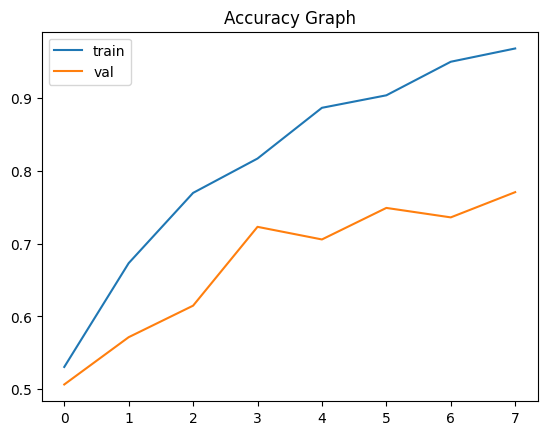

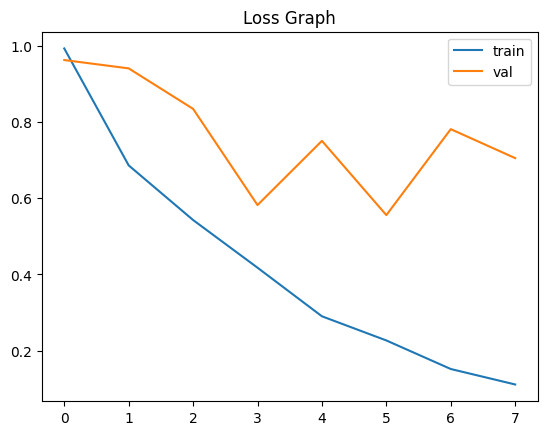

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 195ms/step


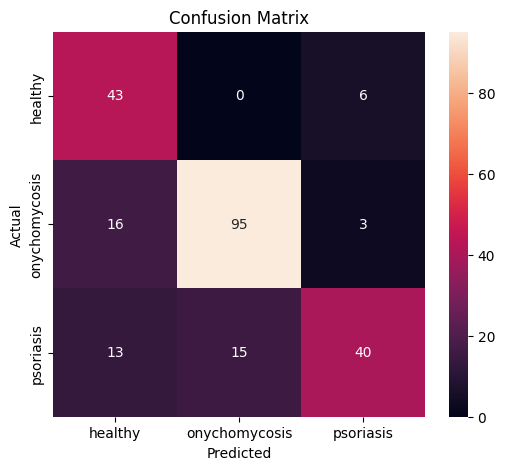


Classification Report:

               precision    recall  f1-score   support

      healthy       0.60      0.88      0.71        49
onychomycosis       0.86      0.83      0.85       114
    psoriasis       0.82      0.59      0.68        68

     accuracy                           0.77       231
    macro avg       0.76      0.77      0.75       231
 weighted avg       0.79      0.77      0.77       231


Upload nail image


Saving psoriasis.jpg to psoriasis (1).jpg
Saving onychomycosis.jpg to onychomycosis (1).jpg
Saving healthy.jpg to healthy (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step


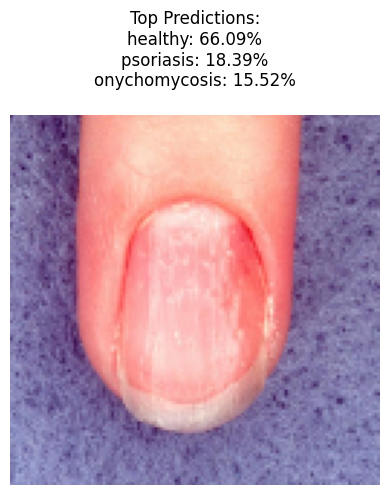

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


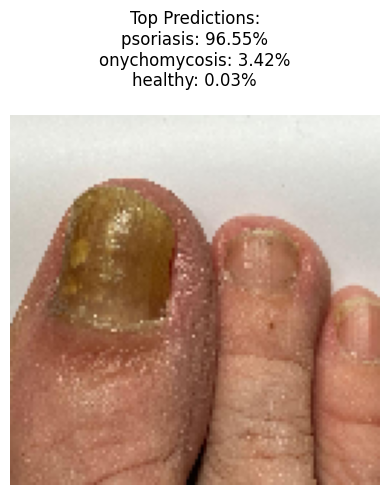

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


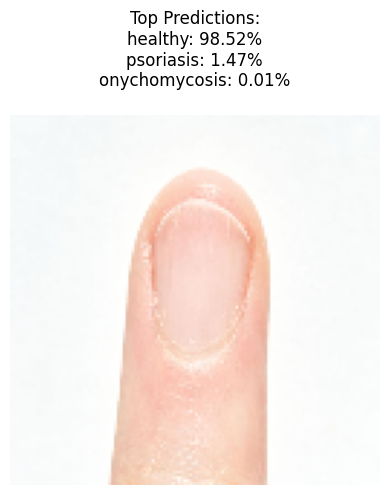

In [ ]:
# =========================
# 1. MOUNT DRIVE
# =========================
from google.colab import drive
drive.mount('/content/drive')

# =========================
# 2. EXTRACT DATASET
# =========================
import zipfile, os

zip_path = '/content/drive/MyDrive/mldl nail.zip'  # change if needed

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/data')

print("Dataset Ready!")

# =========================
# 3. IMPORTS
# =========================
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 4. PATH
# =========================
base_path = '/content/data'
main_folder = os.listdir(base_path)[0]
train_dir = os.path.join(base_path, main_folder, 'train')

# =========================
# 5. DATA GENERATOR
# =========================
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train = datagen.flow_from_directory(
    train_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

valid = datagen.flow_from_directory(
    train_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

class_names = list(train.class_indices.keys())

# =========================
# 6. SIMPLE CNN MODEL
# =========================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(),

    Flatten(),
    Dense(64, activation='relu'),
    Dense(len(class_names), activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# =========================
# 7. TRAIN
# =========================
history = model.fit(train, validation_data=valid, epochs=8)

print("\nFinal Accuracy:", history.history['val_accuracy'][-1])

# =========================
# 8. GRAPHS
# =========================
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy Graph")
plt.legend(['train','val'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss Graph")
plt.legend(['train','val'])
plt.show()

# =========================
# 9. CONFUSION MATRIX
# =========================
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(valid)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = valid.classes

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================
# 10. CLASSIFICATION REPORT
# =========================
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

# =========================
# 11. FINAL DISEASE DETECTION 🔥

def detect_disease():
    from tensorflow.keras.preprocessing import image
    from google.colab import files
    import numpy as np
    import matplotlib.pyplot as plt

    print("\nUpload nail image")
    uploaded = files.upload()

    for fn in uploaded:
        img = image.load_img(fn, target_size=(128,128))
        img_array = image.img_to_array(img)/255.0
        img_array = np.expand_dims(img_array, axis=0)

        pred = model.predict(img_array)[0]

        # Top 3 predictions
        top3 = pred.argsort()[-3:][::-1]

        plt.imshow(img)
        plt.axis('off')

        title = "Top Predictions:\n"
        for i in top3:
            title += f"{class_names[i]}: {pred[i]*100:.2f}%\n"

        plt.title(title)
        plt.show()

# Run anytime (no retraining needed)
detect_disease()


Upload nail image


Saving healthy nail.jpg to healthy nail.jpg
Saving onychomycosis.jpg to onychomycosis (2).jpg
Saving psoriasis.jpg to psoriasis (3).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


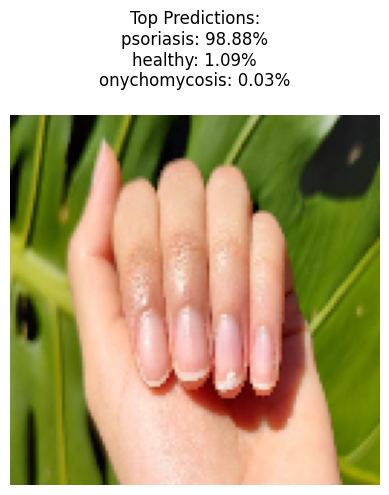

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


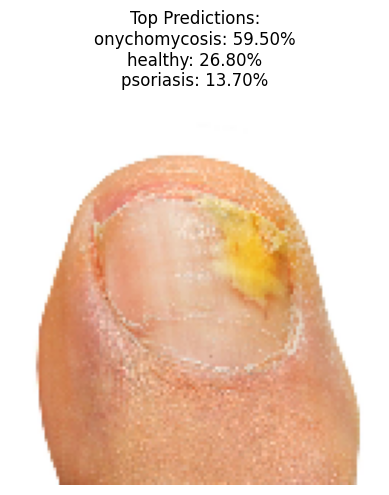

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


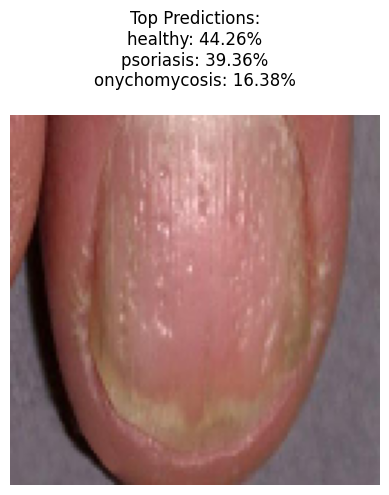

In [ ]:
detect_disease()
